In [1]:
import numpy as np
import pandas as pd 
import os


In [2]:
import sys
print(sys.executable)

c:\AI_Projects\.venv\Scripts\python.exe


In [3]:
trainData = pd.read_csv("../train.csv",low_memory=False)
testData = pd.read_csv("../test.csv",low_memory=False)


# Data Exploration & Visualization

In [4]:
trainData.info()

<class 'pandas.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  str    
 5   VendorPartnerID            138701 non-null  str    
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   str    
 9   TransactionDate            138701 non-null  str    
 10  Spec_FullDescriptor        138701 non-null  str    
 11  Spec_BaseClass             138701 non-null  str    
 12  Spec_SubClass              101716 non-null  str    
 13  Spec_ReleaseSeries         32896 non-nul

In [5]:
trainData.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,NaN,NaN,NaN,2186275.950556,1128496.619347,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,NaN,NaN,NaN,41521.874047,26361.125948,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,NaN,NaN,NaN,1204814.320423,528737.593449,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,NaN,NaN,NaN,7286.421922,7542.421537,39.0,1693.0,3852.0,11873.0,37209.0
DataOriginCode,138701,6,ADI149,59541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VendorPartnerID,138701,31,UJF,67828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufactureYear,138701.0,NaN,NaN,NaN,1891.640853,306.992001,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,NaN,NaN,NaN,4553.718943,27922.04485,0.0,0.0,1620.0,5001.0,1729600.0
UtilizationTier,50475,3,Medium,24588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,138701,3676,2010-02-16,1159,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
trainData.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [7]:
trainData.nunique()

TransactionID                138701
TargetValue                     675
AssetID                      120111
ProductConfigID                3594
DataOriginCode                    6
VendorPartnerID                  31
ManufactureYear                  68
OperationalHoursMeter         14643
UtilizationTier                   3
TransactionDate                3676
Spec_FullDescriptor            3505
Spec_BaseClass                 1249
Spec_SubClass                   147
Spec_ReleaseSeries              113
Spec_VariantModifier            132
AssetScaleFactor                  6
FunctionalClassification         65
RegionCode                       53
InventoryGroupCategory            6
InventoryGroupDescription         6
col1                              4
CabinType                         3
Forks                             2
col3                              3
col4                              2
DrivetrainType                    8
col5                              2
col6                        

In [8]:
trainData.isna().mean()*100

TransactionID                 0.000000
TargetValue                   0.000000
AssetID                       0.000000
ProductConfigID               0.000000
DataOriginCode                0.000000
VendorPartnerID               0.000000
ManufactureYear               0.000000
OperationalHoursMeter        40.838206
UtilizationTier              63.608770
TransactionDate               0.000000
Spec_FullDescriptor           0.000000
Spec_BaseClass                0.000000
Spec_SubClass                26.665273
Spec_ReleaseSeries           76.282795
Spec_VariantModifier         62.269919
AssetScaleFactor             29.711394
FunctionalClassification      0.000000
RegionCode                    0.000000
InventoryGroupCategory        0.000000
InventoryGroupDescription     0.000000
col1                         75.641127
CabinType                     0.000000
Forks                        78.861724
col3                         78.909309
col4                         92.515555
DrivetrainType           

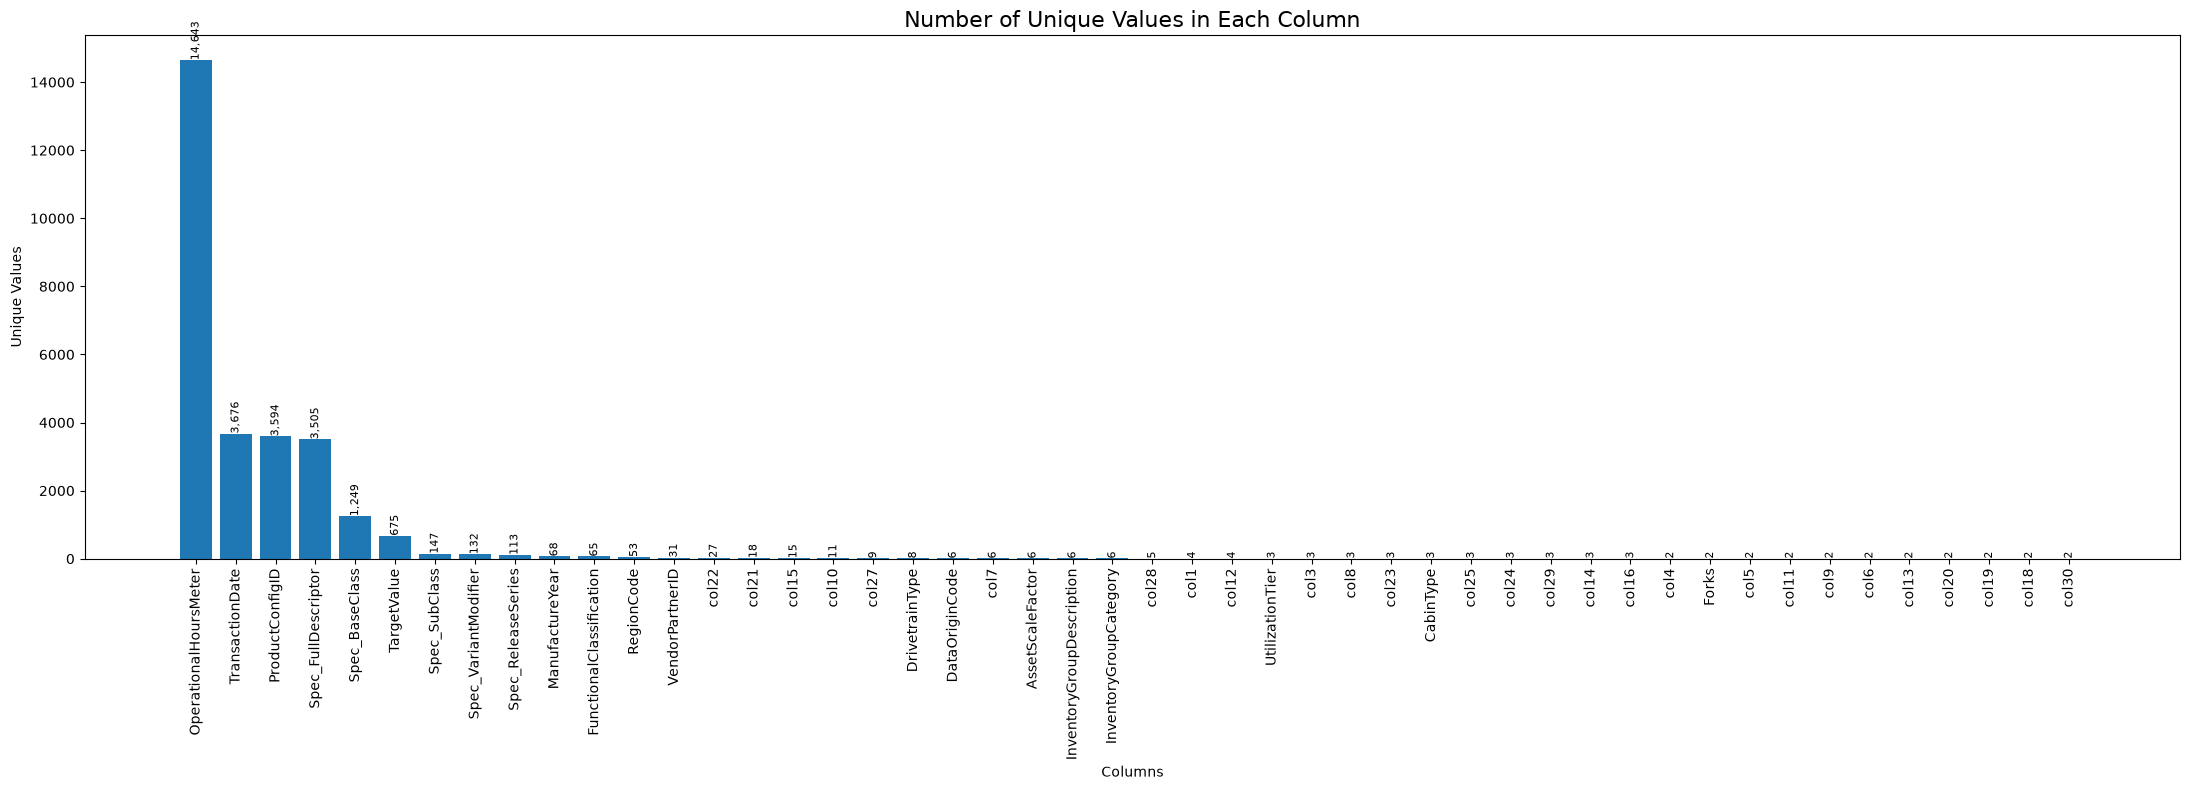

In [9]:
import matplotlib.pyplot as plt

unique_counts = trainData.nunique()

unique_counts = unique_counts.drop(["TransactionID", "AssetID"])

unique_counts = unique_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(22, 8))

bars = ax.bar(unique_counts.index, unique_counts.values)

ax.set_title("Number of Unique Values in Each Column", fontsize=16)
ax.set_xlabel("Columns")
ax.set_ylabel("Unique Values")

plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [10]:
categorical_cols = []

for col in trainData.select_dtypes(include="object"):
    if trainData[col].nunique() <= 30:
        categorical_cols.append(col)

rows = (len(categorical_cols) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = trainData[col].value_counts()

    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=90)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_4496\3855549158.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in trainData.select_dtypes(include="object"):


KeyboardInterrupt: 

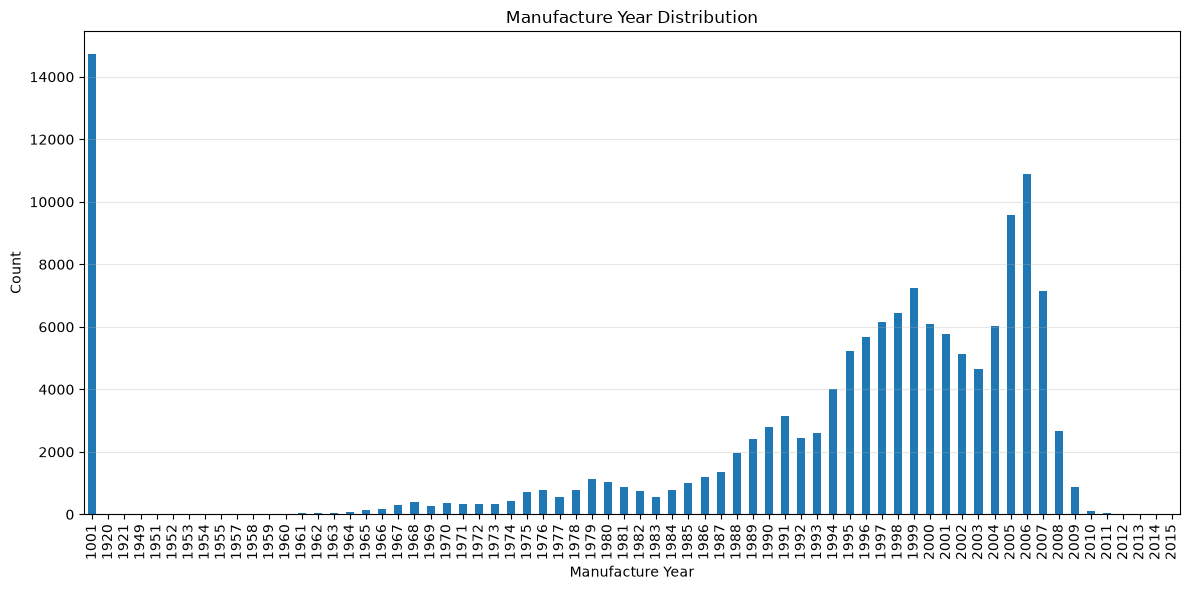

In [ ]:
year_counts = trainData["ManufactureYear"].value_counts().sort_index()

ax = year_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Manufacture Year Distribution")
ax.set_xlabel("Manufacture Year")
ax.set_ylabel("Count")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

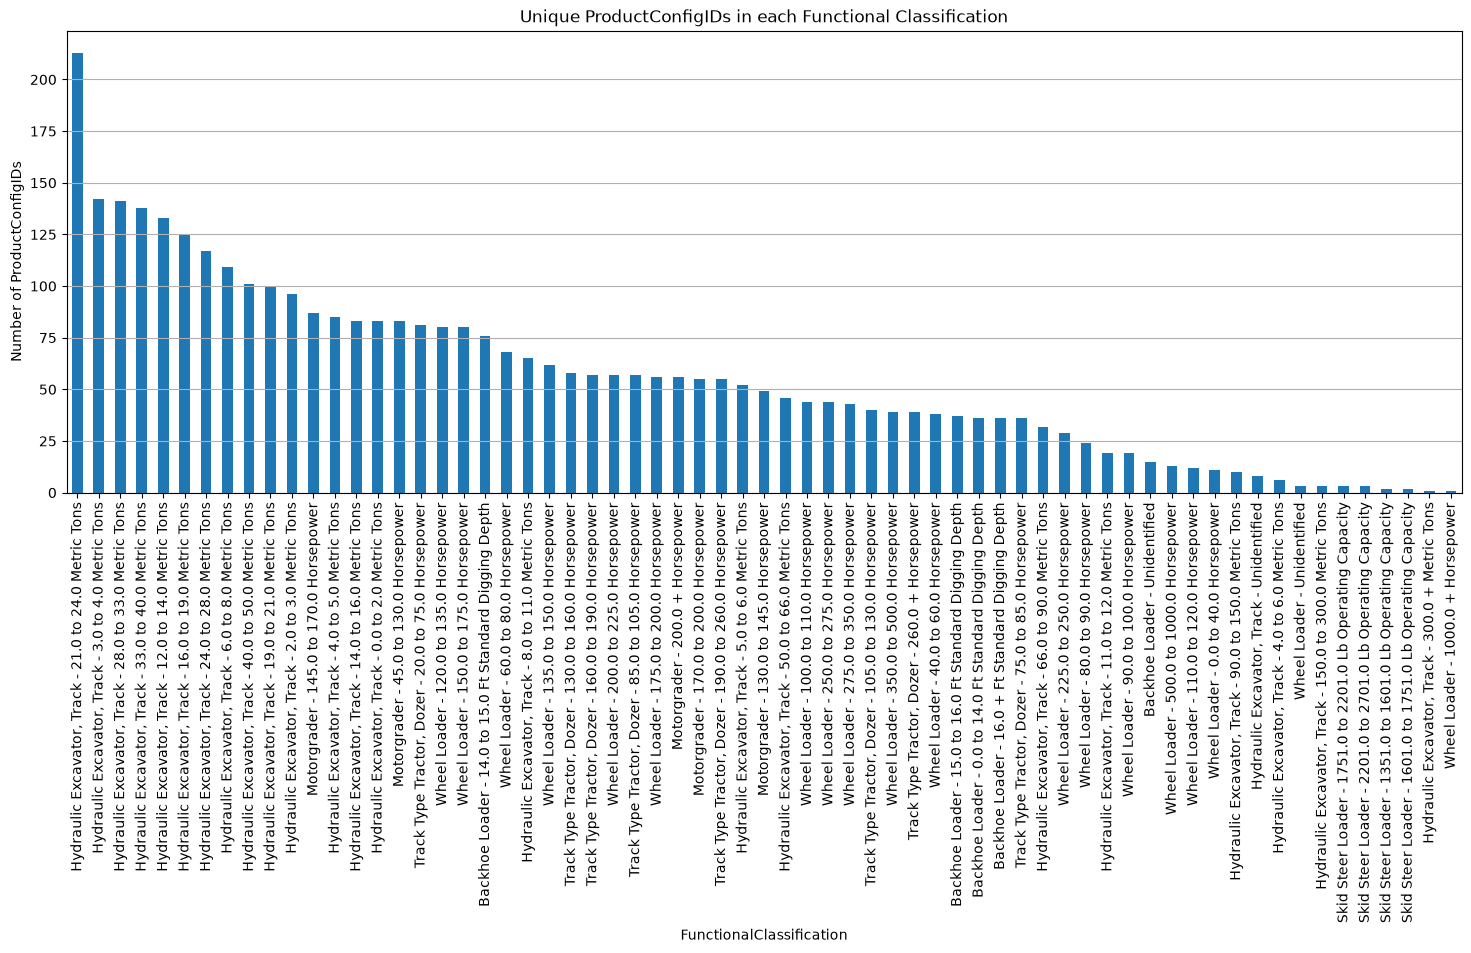

In [ ]:
fc_product = (
    trainData.groupby("FunctionalClassification")["ProductConfigID"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(18,6))
fc_product.plot(kind="bar")
plt.title("Unique ProductConfigIDs in each Functional Classification")
plt.ylabel("Number of ProductConfigIDs")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

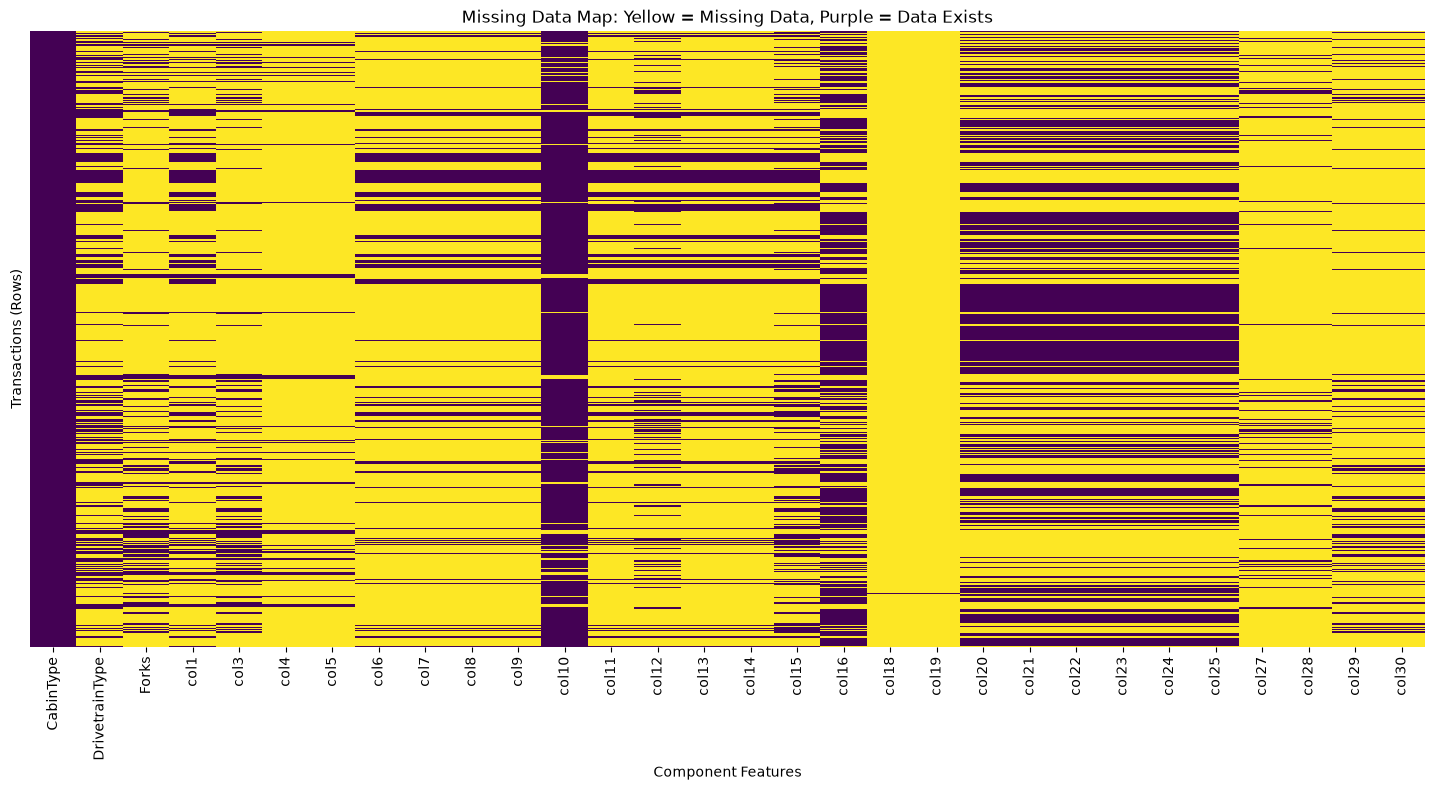

In [ ]:
import seaborn as sns
component_columns = ['CabinType', 'DrivetrainType', 'Forks'] + [col for col in trainData.columns if col.startswith('col')]


missing_data_matrix = trainData[component_columns].isnull()


plt.figure(figsize=(18, 8))

sns.heatmap(missing_data_matrix, cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Data Map: Yellow = Missing Data, Purple = Data Exists')
plt.xlabel('Component Features')
plt.ylabel('Transactions (Rows)')
plt.show()

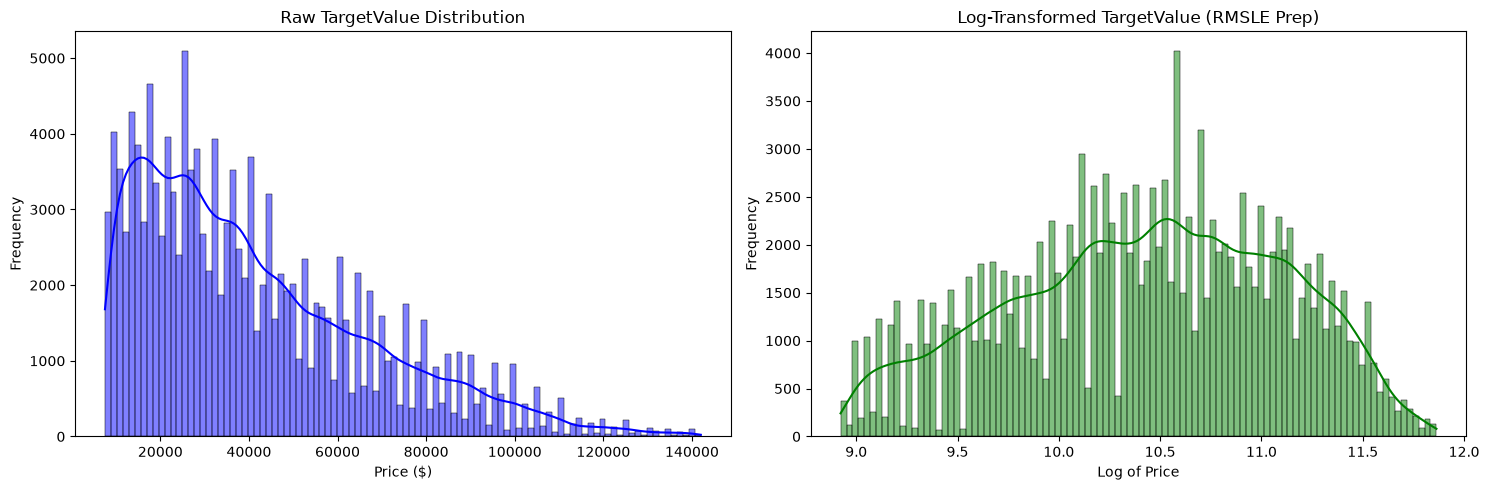

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(trainData['TargetValue'], bins=100, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Raw TargetValue Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')


sns.histplot(np.log1p(trainData['TargetValue']), bins=100, kde=True, ax=axes[1], color='green')
axes[1].set_title('Log-Transformed TargetValue (RMSLE Prep)')
axes[1].set_xlabel('Log of Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
metadata = pd.DataFrame({
    'dtype': trainData.dtypes.astype(str),
    'nulls': trainData.isnull().sum(),
    'null_pct': (trainData.isnull().mean() * 100).round(2),
    'unique': trainData.nunique(),
    'sample_value': trainData.iloc[0]
})
metadata

,dtype,nulls,null_pct,unique,sample_value
TransactionID,int64,0,0.00,138701,1139309
TargetValue,float64,0,0.00,675,57000.0
AssetID,int64,0,0.00,120111,117665
ProductConfigID,int64,0,0.00,3594,88
DataOriginCode,str,0,0.00,6,ACH138
VendorPartnerID,str,0,0.00,31,GTX
ManufactureYear,int64,0,0.00,68,1997
OperationalHoursMeter,float64,56643,40.84,14643,4640.0
UtilizationTier,str,88226,63.61,3,Low
TransactionDate,str,0,0.00,3676,2005-03-26


In [ ]:

component_columns = ['CabinType', 'DrivetrainType', 'Forks'] + [col for col in trainData.columns if col.startswith('col')]


for col in component_columns:
    print(f"Unique Values in {col} ")
    print(trainData[col].value_counts(dropna=False) )
    print("\n")

Unique Values in CabinType 
CabinType
EROPS         60189
EROPS w AC    55752
OROPS         22760
Name: count, dtype: int64


Unique Values in DrivetrainType 
DrivetrainType
NaN                    89956
None or Unspecified    21482
Standard               20072
Powershift              4700
Hydrostatic             1398
Powershuttle            1006
AutoShift                 41
Autoshift                 32
Direct Drive              14
Name: count, dtype: int64


Unique Values in Forks 
Forks
NaN                    109382
None or Unspecified     24839
Yes                      4480
Name: count, dtype: int64


Unique Values in col1 
col1
NaN                 104915
No                   22667
Two Wheel Drive       5600
Four Wheel Drive      4781
All Wheel Drive        738
Name: count, dtype: int64


Unique Values in col3 
col3
NaN                    109448
None or Unspecified     14923
No                       9593
Yes                      4737
Name: count, dtype: int64


Unique Values in col4 

In [ ]:

spec_columns = ['Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'Spec_FullDescriptor']

for col in spec_columns:
    print(f"Categories in {col}")
    print(trainData[col].value_counts(dropna=False))
    print("\n")

Categories in Spec_BaseClass
Spec_BaseClass
12           5702
140          5378
320          4605
D6           4347
330          3870
             ... 
336             1
ZX180           1
ROBEX 180       1
PC05            1
716             1
Name: count, Length: 1249, dtype: int64


Categories in Spec_SubClass
Spec_SubClass
NaN     36985
G       17381
B       16445
C       16025
H        8004
        ...  
BLGP        1
BH          1
SRDZ        1
BLT         1
NLC         1
Name: count, Length: 148, dtype: int64


Categories in Spec_ReleaseSeries
Spec_ReleaseSeries
NaN    105805
II       8425
LC       7724
-2       2744
-5       1467
        ...  
WT          1
6L          1
7L          1
Q           1
VII         1
Name: count, Length: 114, dtype: int64


Categories in Spec_VariantModifier
Spec_VariantModifier
NaN         86369
L           14496
LC          11920
LGP          5947
XL           3443
            ...  
HighLift        1
VHP/AWD         1
K3              1
LITRONIC      

In [ ]:
import re
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# Feature Engineering 

In [ ]:
train_ids = trainData["TransactionID"].copy()
test_ids = testData["TransactionID"].copy()

### Smooth Target Encoding of the categorical columns

In [ ]:
class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, columns, alpha=15):
        self.columns = columns
        self.alpha = alpha
        self.global_mean = None
        self.category_means = {}

    def fit(self, X, y):
        
        self.global_mean = y.mean()

        for col in self.columns:

            grouped = pd.DataFrame({
                "target": y,
                "category": X[col]
            })
            stats = grouped.groupby("category")["target"].agg(["mean", "count"])

            self.category_means[col] = (
                (stats["mean"] * stats["count"] + self.alpha * self.global_mean)
                / (stats["count"] + self.alpha)
            )
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:

            X[col] = X[col].map(self.category_means[col])
            X[col] = X[col].fillna(self.global_mean)

        return X

In [ ]:
def parse_functional_classification(df):

    if "FunctionalClassification" not in df.columns:
        return df

    data = df.copy()

   
    fc = data["FunctionalClassification"].fillna("Unidentified")

    split_data = fc.str.split(r"\s*-\s*", n=1, expand=True)


    machine = split_data[0].str.split(",", n=1, expand=True)

    data["FC_MachineFamily"] = machine[0].str.strip()
    data["FC_DriveType"] = machine[1].fillna("None").str.strip()

 
    specs = split_data[1].fillna("Unidentified")

    lower = specs.str.extract(r"(\d+\.?\d*)")[0]
    upper = specs.str.extract(r"to\s*(\d+\.?\d*)")[0]
    unit = specs.str.extract(r"(Metric Tons|Horsepower|Ft[^,]*|Lb[^,]*)")[0]

    data["FC_LowerBound"] = lower.astype(float)
    data["FC_UpperBound"] = upper.astype(float)
    data["FC_Unit"] = unit.fillna("Unknown")

    data["FC_IsPlusRange"] = specs.str.contains(r"\+").astype(int)
    data["FC_RangeKnown"] = (~specs.str.contains("Unidentified")).astype(int)

    return data

In [ ]:
def clean_machine_measurements(df):

    data = df.copy()

    if "col7" in data.columns:
        values = data["col7"].astype(str).str.replace(r"[<' ]", "", regex=True)
        data["col7_Numeric_Feet"] = pd.to_numeric(values, errors="coerce")
        data.drop(columns="col7", inplace=True)

    if "col15" in data.columns:
        values = data["col15"].astype(str).str.replace('"', "", regex=False)
        data["col15_Numeric_Inches"] = pd.to_numeric(values, errors="coerce")
        data.drop(columns="col15", inplace=True)

    if "col21" in data.columns:
        values = (
            data["col21"]
            .astype(str)
            .str.replace(" inch", "", regex=False)
            .str.strip()
        )

        data["col21_Numeric_Inches"] = pd.to_numeric(values, errors="coerce")
        data.drop(columns="col21", inplace=True)

    if "col22" in data.columns:

        def convert_reach(value):

            if pd.isna(value):
                return np.nan

            value = str(value).strip()

            if value.lower() in {
                "none",
                "nan",
                "not applicable",
                "none or unspecified",
                ""
            }:
                return np.nan

            match = re.match(r"(\d+)\s*'\s*(\d*)\s*\"?", value)
            if match:
                feet = float(match.group(1))
                inches = float(match.group(2) or 0)
                return feet * 12 + inches

            return np.nan

        data["col22_Total_Inches"] = data["col22"].apply(convert_reach)
        data.drop(columns="col22", inplace=True)

    return data

### Categorical Columns with more than 20 % null values

In [ ]:
missing_ratio = trainData.isnull().mean()

fill_cols = missing_ratio[
    (missing_ratio > 0.20) &
    (trainData.dtypes == "object")
].index.tolist()
fill_cols

[]

### In Fill_Cols , Columns which are not unknown(col) columns

In [ ]:
fill_cols = [c for c in fill_cols if not c.startswith("col")]
fill_cols

[]

### Unknown/Machine related columns which starts with 'col'

In [ ]:
machine_cols = [
    c for c in trainData.select_dtypes(include="object").columns
    if c.startswith("col")
]

/tmp/ipykernel_37520/1506893879.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in trainData.select_dtypes(include="object").columns


## Feature Engineering and Transformations

In [ ]:

def feature_engineering(df, fill_cols, machine_cols):
    df = df.copy()
    df.drop(columns=["TransactionID","InventoryGroupCategory","col18","col19",],errors="ignore",inplace=True)

    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

    df["TransactionYear"] = df["TransactionDate"].dt.year
    df["TransactionMonth"] = df["TransactionDate"].dt.month
    df["TransactionQuarter"] = df["TransactionDate"].dt.quarter
    df["TransactionDay"] = df["TransactionDate"].dt.day
    df["TransactionDayOfWeek"] = df["TransactionDate"].dt.dayofweek

    df.drop(columns="TransactionDate", inplace=True)

    df["ManufactureYearMissing"] = (df["ManufactureYear"].isin([1000, 1001]).astype(int))
    df["ManufactureYear"] = (df["ManufactureYear"].replace([1000, 1001], np.nan))
    df["AssetAge"] = (df["TransactionYear"] -df["ManufactureYear"])
    df.loc[df["AssetAge"] < 0, "AssetAge"] = np.nan
    df["HoursMissing"] = (df["OperationalHoursMeter"].isna().astype(int))

    df["Missing_BaseClass"] = (df["Spec_BaseClass"].isna().astype(int))
    for col in fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")

    for col in machine_cols:
        if col in df.columns:
            df[col] = df[col].fillna("Not Applicable")

    return df

In [ ]:
class DataTransformer:

    def __init__(self, num_strategy="median"):
        self.num_imputer = SimpleImputer(strategy=num_strategy)
        self.ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1, encoded_missing_value=-1)
    def fit(self, X):
        X = X.copy()
        self.num_cols = [
            col
            for col in X.select_dtypes(include="number").columns
            if col not in ["TargetValue", "TransactionID", "AssetID"]
            and X[col].isna().any()]

        self.cat_cols = (X.select_dtypes(include="object").columns.tolist())
        self.num_imputer.fit(X[self.num_cols])

        self.ordinal_encoder.fit(X[self.cat_cols].astype(str))

        return self

    def transform(self, X):
        X = X.copy()
        if self.num_cols:
            X[self.num_cols] = self.num_imputer.transform(X[self.num_cols])
      
        X["OperationalHoursLog"] = np.log1p(X["OperationalHoursMeter"])
        X["HoursPerYear"] = (X["OperationalHoursMeter"]/ (X["AssetAge"] + 1))

        if self.cat_cols:
            X[self.cat_cols] = self.ordinal_encoder.transform(X[self.cat_cols].astype(str))
            X[self.cat_cols] = X[self.cat_cols].astype(int)

        X.drop(columns=["TransactionID", "AssetID"],errors="ignore",inplace=True)

        return X

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [ ]:
trainData = parse_functional_classification(trainData)
trainData = clean_machine_measurements(trainData)

trainData = feature_engineering(trainData,fill_cols,machine_cols)

transformer= DataTransformer()
trainData=transformer.fit_transform(trainData)

/tmp/ipykernel_37520/1151813184.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  self.cat_cols = (X.select_dtypes(include="object").columns.tolist())


In [ ]:
testData = parse_functional_classification(testData)
testData = clean_machine_measurements(testData)

testData = feature_engineering(testData,fill_cols,machine_cols)

testData = transformer.transform(testData)

In [ ]:
target_cols = [
    c for c in transformer.cat_cols 
    if trainData[c].nunique() > 20
]
target_cols

['VendorPartnerID',
 'Spec_FullDescriptor',
 'Spec_BaseClass',
 'Spec_SubClass',
 'Spec_ReleaseSeries',
 'Spec_VariantModifier',
 'FunctionalClassification',
 'RegionCode']

In [ ]:
y = trainData["TargetValue"]
X = trainData.drop(columns=["TargetValue"])
X_test = testData.copy()
y_log = np.log1p(y)

In [ ]:
cat_features = [c for c in transformer.cat_cols if c in X.columns]

In [ ]:
target_cols = [c for c in target_cols if c in X.columns]
target_cols

['VendorPartnerID',
 'Spec_FullDescriptor',
 'Spec_BaseClass',
 'Spec_SubClass',
 'Spec_ReleaseSeries',
 'Spec_VariantModifier',
 'FunctionalClassification',
 'RegionCode']

# Model Training

In [ ]:
models = {

    "xgb": xgb.XGBRegressor(
        n_estimators=12000,
        learning_rate=0.018,
        max_depth=8,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=3,
        reg_alpha=0.1,
        tree_method="hist",
        early_stopping_rounds=300,
        random_state=42,
        n_jobs=-1
    ),


    "lgb": lgb.LGBMRegressor(
        n_estimators=12000,
        learning_rate=0.018,
        num_leaves=80,
        min_child_samples=30,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=3,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),


    "cat": CatBoostRegressor(
        iterations=12000,
        learning_rate=0.018,
        depth=8,
        l2_leaf_reg=5,
        loss_function="RMSE",
        random_seed=42,
        early_stopping_rounds=300,
        verbose=0
    )

}

In [ ]:
def train_models(models, X, y_log, X_test):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    oof = {name: np.zeros(len(X)) for name in models}
    test_preds = {name: np.zeros(len(X_test)) for name in models}

    train_scores = {name: [] for name in models}
    val_scores = {name: [] for name in models}
    fold_numbers = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    
        print(f"\nFold {fold}")
    
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
    
        y_train = y_log.iloc[train_idx]
        y_val = y_log.iloc[val_idx]
    
        # Target Encoding (only for XGB & LGB)
        encoder = SmoothedTargetEncoder(
            columns=target_cols,
            alpha=15
        )
    
        X_train_enc = encoder.fit_transform(X_train, y_train)
        X_val_enc = encoder.transform(X_val)
        X_test_enc = encoder.transform(X_test)
    
        fold_numbers.append(fold)
    
        for name, model in models.items():
    
       
            if name == "cat":
    
                model.fit(
                    X_train,
                    y_train,
                    eval_set=(X_val, y_val),
                    use_best_model=True
                )
    
                train_pred = model.predict(X_train)
                val_pred = model.predict(X_val)
    
                test_preds[name] += (model.predict(X_test) / kf.n_splits)
    
            elif name == "lgb":
    
                model.fit(
                    X_train_enc,
                    y_train,
                    eval_set=[(X_val_enc, y_val)],
                    callbacks=[
                        lgb.early_stopping(
                            300,
                            verbose=False
                        )
                    ]
                )
    
                train_pred = model.predict(X_train_enc)
                val_pred = model.predict(X_val_enc)
    
                test_preds[name] += (model.predict(X_test_enc) / kf.n_splits)
                print(model.n_estimators_)
    
            else:   # XGBoost
    
                model.fit(
                    X_train_enc,
                    y_train,
                    eval_set=[(X_val_enc, y_val)],
                    verbose=500
                )
    
                train_pred = model.predict(X_train_enc)
                val_pred = model.predict(X_val_enc)
    
                test_preds[name] += (
                    model.predict(X_test_enc) / kf.n_splits
                )
    
            oof[name][val_idx] = val_pred
    
        
            train_score = np.sqrt(
                mean_squared_log_error(
                    np.expm1(y_train),
                    np.expm1(train_pred)
                )
            )
    
            val_score = np.sqrt(
                mean_squared_log_error(
                    np.expm1(y_val),
                    np.expm1(val_pred)
                )
            )
    
            train_scores[name].append(train_score)
            val_scores[name].append(val_score)
    
            print(f"{name.upper()} : {val_score:.5f}")
    

   

    return (
        oof,
        test_preds,
        train_scores,
        val_scores
    )

In [ ]:
oof, test_preds, train_scores, val_scores = train_models(
    models,
    X,
    y_log,
    X_test
)


Fold 1
[0]	validation_0-rmse:0.65968
[500]	validation_0-rmse:0.22041


KeyboardInterrupt: 

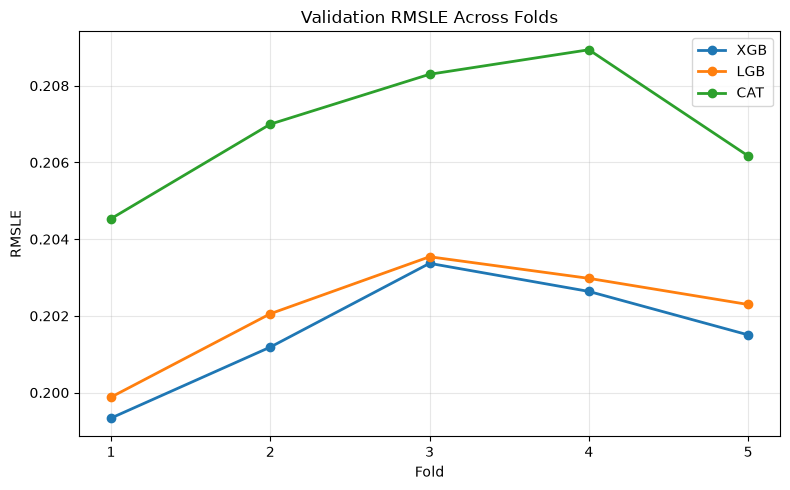

In [ ]:
folds = range(1, len(val_scores["xgb"]) + 1)

plt.figure(figsize=(8, 5))

for model in ["xgb", "lgb", "cat"]:
    plt.plot(
        folds,
        val_scores[model],
        marker="o",
        linewidth=2,
        label=model.upper()
    )

plt.title("Validation RMSLE Across Folds")
plt.xlabel("Fold")
plt.ylabel("RMSLE")
plt.xticks(folds)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Hyperparameter tuning

In [ ]:
xgb_param_grid = {
    "max_depth": [7, 8, 9],
    "min_child_weight": [4, 5, 6],
    "learning_rate": [0.018, 0.020, 0.022],
    "subsample": [0.82, 0.85, 0.88],
    "colsample_bytree": [0.82, 0.85, 0.88],
    "reg_alpha": [0.05, 0.10, 0.15],
    "reg_lambda": [2.5, 3.0, 4.0]
}
lgb_param_grid = {
    "num_leaves": [72, 80, 88],
    "min_child_samples": [25, 30, 35],
    "learning_rate": [0.018, 0.020, 0.022],
    "subsample": [0.83, 0.85, 0.87],
    "colsample_bytree": [0.83, 0.85, 0.87],
    "reg_lambda": [2.5, 3.0, 3.5]

}

cat_param_grid = {
    "depth": [7, 8, 9],
    "learning_rate": [0.018, 0.020, 0.022],
    "l2_leaf_reg": [4, 5, 6]
}

In [ ]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)


xgb_base = xgb.XGBRegressor(
    n_estimators=8000,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

lgb_base = lgb.LGBMRegressor(
    n_estimators=8000,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cat_base = CatBoostRegressor(
    iterations=8000,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)


baseline_scores = {
    "xgb": np.mean(val_scores["xgb"]),
    "lgb": np.mean(val_scores["lgb"]),
    "cat": np.mean(val_scores["cat"])
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

def tune_model(
    model_name,
    estimator,
    param_grid,
    X,
    y_log,
    kf,
    baseline_score,
    target_encode=False,
    target_cols=None,
    n_iter=3
):

    print(f"\nTuning {model_name.upper()}...")

    X_train = X.copy()

    if target_encode:
        encoder = SmoothedTargetEncoder(columns=target_cols, alpha=15)
        X_train = encoder.fit_transform(X_train, y_log)

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        random_state=42,
        n_jobs=1,
        verbose=3
    )
    search.fit(X_train, y_log)

    score = -search.best_score_

    print(f"Baseline Score : {baseline_score:.5f}")
    print(f"Best CV Score  : {score:.5f}")
    print("Best Parameters:")
    print(search.best_params_)

    if score < baseline_score:
        print("Using tuned parameters.\n")
        return search.best_params_

    print("Keeping original parameters.\n")
    return None

In [ ]:
# XGBoost hyperparameter tuning
xgb_best_params = tune_model(
    "xgb",
    xgb_base,
    xgb_param_grid,
    X,
    y_log,
    kf,
    baseline_scores["xgb"],
    target_encode=True,
    target_cols=target_cols,
    n_iter=5
)

if xgb_best_params:
    models["xgb"] = xgb.XGBRegressor(
        n_estimators=12000,
        tree_method="hist",
        early_stopping_rounds=300,
        random_state=42,
        n_jobs=-1,
        **xgb_best_params
    )


Tuning XGB...


Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END colsample_bytree=0.85, learning_rate=0.018, max_depth=8, min_child_weight=5, reg_alpha=0.15, reg_lambda=3.0, subsample=0.88;, score=-0.195 total time=26.7min
[CV 2/5] END colsample_bytree=0.85, learning_rate=0.018, max_depth=8, min_child_weight=5, reg_alpha=0.15, reg_lambda=3.0, subsample=0.88;, score=-0.196 total time= 7.9min
[CV 3/5] END colsample_bytree=0.85, learning_rate=0.018, max_depth=8, min_child_weight=5, reg_alpha=0.15, reg_lambda=3.0, subsample=0.88;, score=-0.198 total time= 1.5min
[CV 4/5] END colsample_bytree=0.85, learning_rate=0.018, max_depth=8, min_child_weight=5, reg_alpha=0.15, reg_lambda=3.0, subsample=0.88;, score=-0.198 total time= 1.2min
[CV 5/5] END colsample_bytree=0.85, learning_rate=0.018, max_depth=8, min_child_weight=5, reg_alpha=0.15, reg_lambda=3.0, subsample=0.88;, score=-0.197 total time= 1.6min
[CV 1/5] END colsample_bytree=0.85, learning_rate=0.022, max_depth=7, min_child_weigh

In [ ]:
# LightGBM hyperparameter tuning
lgb_best_params = tune_model(
    "lgb",
    lgb_base,
    lgb_param_grid,
    X,
    y_log,
    kf,
    baseline_scores["lgb"],
    target_encode=True,
    target_cols=target_cols,
    n_iter=5
)

if lgb_best_params:
    models["lgb"] = lgb.LGBMRegressor(
        n_estimators=12000,
        random_state=42,
        early_stopping_rounds=300,
        n_jobs=-1,
        verbose=-1,
        **lgb_best_params
    )


Tuning LGB...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END colsample_bytree=0.83, learning_rate=0.02, min_child_samples=25, num_leaves=88, reg_lambda=3.0, subsample=0.83;, score=-0.196 total time= 1.4min
[CV 2/5] END colsample_bytree=0.83, learning_rate=0.02, min_child_samples=25, num_leaves=88, reg_lambda=3.0, subsample=0.83;, score=-0.198 total time= 1.4min
[CV 3/5] END colsample_bytree=0.83, learning_rate=0.02, min_child_samples=25, num_leaves=88, reg_lambda=3.0, subsample=0.83;, score=-0.199 total time= 1.4min
[CV 4/5] END colsample_bytree=0.83, learning_rate=0.02, min_child_samples=25, num_leaves=88, reg_lambda=3.0, subsample=0.83;, score=-0.199 total time= 1.4min
[CV 5/5] END colsample_bytree=0.83, learning_rate=0.02, min_child_samples=25, num_leaves=88, reg_lambda=3.0, subsample=0.83;, score=-0.198 total time= 1.4min
[CV 1/5] END colsample_bytree=0.85, learning_rate=0.022, min_child_samples=30, num_leaves=72, reg_lambda=3.0, subsample=0.83;, score=-0

In [ ]:
# CatBoost hyperparameter tuning
cat_best_params = tune_model(
    "cat",
    cat_base,
    cat_param_grid,
    X,
    y_log,
    kf,
    baseline_scores["cat"],
    target_encode=False,
    n_iter=5
)

if cat_best_params:
    models["cat"] = CatBoostRegressor(
        iterations=12000,
        loss_function="RMSE",
        random_seed=42,
        verbose=0,
        **cat_best_params
    )


Tuning CAT...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END depth=7, l2_leaf_reg=6, learning_rate=0.022;, score=-0.210 total time= 2.6min
[CV 2/5] END depth=7, l2_leaf_reg=6, learning_rate=0.022;, score=-0.212 total time= 2.7min
[CV 3/5] END depth=7, l2_leaf_reg=6, learning_rate=0.022;, score=-0.213 total time= 2.6min
[CV 4/5] END depth=7, l2_leaf_reg=6, learning_rate=0.022;, score=-0.214 total time= 2.6min
[CV 5/5] END depth=7, l2_leaf_reg=6, learning_rate=0.022;, score=-0.211 total time= 2.7min
[CV 1/5] END depth=8, l2_leaf_reg=5, learning_rate=0.02;, score=-0.208 total time= 3.3min
[CV 2/5] END depth=8, l2_leaf_reg=5, learning_rate=0.02;, score=-0.210 total time= 3.5min
[CV 3/5] END depth=8, l2_leaf_reg=5, learning_rate=0.02;, score=-0.211 total time= 3.5min
[CV 4/5] END depth=8, l2_leaf_reg=5, learning_rate=0.02;, score=-0.212 total time= 3.5min
[CV 5/5] END depth=8, l2_leaf_reg=5, learning_rate=0.02;, score=-0.209 total time= 3.4min
[CV 1/5] END depth=8

In [ ]:
oof, test_preds, train_scores, val_scores = train_models(
    models,
    X,
    y_log,
    X_test
)


Fold 1
[0]	validation_0-rmse:0.65952
[500]	validation_0-rmse:0.21595
[1000]	validation_0-rmse:0.20850
[1500]	validation_0-rmse:0.20505
[2000]	validation_0-rmse:0.20305
[2500]	validation_0-rmse:0.20175
[3000]	validation_0-rmse:0.20088
[3500]	validation_0-rmse:0.20029
[4000]	validation_0-rmse:0.19989
[4500]	validation_0-rmse:0.19967
[5000]	validation_0-rmse:0.19954
[5500]	validation_0-rmse:0.19944
[6000]	validation_0-rmse:0.19940
[6291]	validation_0-rmse:0.19943
XGB : 0.19940
11992
LGB : 0.19951
CAT : 0.20541

Fold 2
[0]	validation_0-rmse:0.66235
[500]	validation_0-rmse:0.21796
[1000]	validation_0-rmse:0.21060
[1500]	validation_0-rmse:0.20707
[2000]	validation_0-rmse:0.20501
[2500]	validation_0-rmse:0.20374
[3000]	validation_0-rmse:0.20294
[3500]	validation_0-rmse:0.20237
[4000]	validation_0-rmse:0.20198
[4500]	validation_0-rmse:0.20177
[5000]	validation_0-rmse:0.20162
[5500]	validation_0-rmse:0.20158
[6000]	validation_0-rmse:0.20155
[6500]	validation_0-rmse:0.20150
[6842]	validation_0-

In [ ]:
print("\nFinal Validation Scores")

for model in val_scores:
    print(f"{model.upper()} : {np.mean(val_scores[model]):.5f}")


Final Validation Scores
XGB : 0.20173
LGB : 0.20178
CAT : 0.20749


### Stacking

In [ ]:
train_stack = np.column_stack([
    oof["xgb"],
    oof["lgb"],
    oof["cat"]
])

test_stack = np.column_stack([
    test_preds["xgb"],
    test_preds["lgb"],
    test_preds["cat"]
])

stack_oof = np.zeros(len(X))

stack_train_scores = []
stack_val_scores = []

kf_stack = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(kf_stack.split(train_stack), 1):

    X_train = train_stack[train_idx]
    X_val = train_stack[val_idx]

    y_train = y_log.iloc[train_idx]
    y_val = y_log.iloc[val_idx]

    model = Ridge(alpha=1.0)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    stack_oof[val_idx] = val_pred

    train_score = np.sqrt(
        mean_squared_log_error(
            np.expm1(y_train),
            np.expm1(train_pred)
        )
    )

    val_score = np.sqrt(
        mean_squared_log_error(
            np.expm1(y_val),
            np.expm1(val_pred)
        )
    )

    stack_train_scores.append(train_score)
    stack_val_scores.append(val_score)

    print(
        f"Fold {fold} | "
        f"Train RMSLE: {train_score:.5f} | "
        f"Validation RMSLE: {val_score:.5f}"
    )

stack_score = np.sqrt(
    mean_squared_log_error(
        y,
        np.expm1(stack_oof)
    )
)



Fold 1 | Train RMSLE: 0.19863 | Validation RMSLE: 0.19585
Fold 2 | Train RMSLE: 0.19818 | Validation RMSLE: 0.19767
Fold 3 | Train RMSLE: 0.19767 | Validation RMSLE: 0.19969
Fold 4 | Train RMSLE: 0.19778 | Validation RMSLE: 0.19926
Fold 5 | Train RMSLE: 0.19812 | Validation RMSLE: 0.19793


In [ ]:
print("\nStacking Results")
print(f"Average Train RMSLE      : {np.mean(stack_train_scores):.5f}")
print(f"Average Validation RMSLE : {np.mean(stack_val_scores):.5f}")
print(f"Overall OOF RMSLE        : {stack_score:.5f}")


# Train final Ridge model on all data
final_meta_model = Ridge(alpha=1.0)

final_meta_model.fit(
    train_stack,
    y_log
)

stack_test = final_meta_model.predict(test_stack)


Stacking Results
Average Train RMSLE      : 0.19808
Average Validation RMSLE : 0.19808
Overall OOF RMSLE        : 0.19808


# Prediction and Submission

In [ ]:

final_predictions = np.maximum(np.expm1(stack_test), 0)

In [ ]:
submission = pd.DataFrame({
    "TransactionID":test_ids,
    "TargetValue":final_predictions
})
submission.to_csv(
    "submission.csv",
    index=False
)
submission.head(10)

,TransactionID,TargetValue
0,1139307,65333.148940
1,1139419,79974.332243
2,1139482,31491.835056
3,1139522,19018.388656
4,1139684,12189.460507
5,1139773,28731.461803
6,1139779,20424.608479
7,1139793,45983.395935
8,1139814,74308.105473
9,1139839,15318.731807


In [ ]:
"""import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error


y = trainData["TargetValue"]
X = trainData.drop(columns=["TargetValue"])
X_test = testData.copy()


kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_lgb = np.zeros(len(X))
test_preds_lgb = np.zeros(len(X_test))
cv_scores_lgb = []"""

'import lightgbm as lgb\nfrom sklearn.model_selection import KFold\nfrom sklearn.metrics import mean_squared_log_error\n\n\ny = trainData["TargetValue"]\nX = trainData.drop(columns=["TargetValue"])\nX_test = testData.copy()\n\n\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\noof_preds_lgb = np.zeros(len(X))\ntest_preds_lgb = np.zeros(len(X_test))\ncv_scores_lgb = []'

In [ ]:
"""fold_number = 1

for train_index, valid_index in kf.split(X):
    print("\nFold", fold_number)

    X_train = X.iloc[train_index]
    X_valid = X.iloc[valid_index]

    
    y_train = np.log1p(y.iloc[train_index])
    y_valid = np.log1p(y.iloc[valid_index])

    
    model = lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=8,
        num_leaves=64,           
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    
    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            lgb.log_evaluation(period=500)
        ]
    )

    
    valid_pred = model.predict(X_valid)
    valid_pred = np.expm1(valid_pred)
    valid_pred = np.maximum(valid_pred, 0)

    
    test_pred = model.predict(X_test)
    test_pred = np.expm1(test_pred)
    test_pred = np.maximum(test_pred, 0)

    
    y_true_valid = y.iloc[valid_index]
    score = np.sqrt(mean_squared_log_error(y_true_valid, valid_pred))
    cv_scores_lgb.append(score)

    
    oof_preds_lgb[valid_index] = valid_pred
    test_preds_lgb = test_preds_lgb + (test_pred / 5)

    print("Fold RMSLE :", round(score, 5))
    
    fold_number = fold_number + 1"""

'fold_number = 1\n\nfor train_index, valid_index in kf.split(X):\n    print("\nFold", fold_number)\n\n    X_train = X.iloc[train_index]\n    X_valid = X.iloc[valid_index]\n\n    \n    y_train = np.log1p(y.iloc[train_index])\n    y_valid = np.log1p(y.iloc[valid_index])\n\n    \n    model = lgb.LGBMRegressor(\n        n_estimators=3000,\n        learning_rate=0.03,\n        max_depth=8,\n        num_leaves=64,           \n        subsample=0.8,\n        colsample_bytree=0.8,\n        random_state=42,\n        n_jobs=-1\n    )\n\n    \n    model.fit(\n        X_train, \n        y_train,\n        eval_set=[(X_valid, y_valid)],\n        callbacks=[\n            lgb.early_stopping(stopping_rounds=200, verbose=False),\n            lgb.log_evaluation(period=500)\n        ]\n    )\n\n    \n    valid_pred = model.predict(X_valid)\n    valid_pred = np.expm1(valid_pred)\n    valid_pred = np.maximum(valid_pred, 0)\n\n    \n    test_pred = model.predict(X_test)\n    test_pred = np.expm1(test_pred)\n

In [ ]:
"""print("\nCV Results (LightGBM)")
for i in range(len(cv_scores_lgb)):
    print("Fold " + str(i+1) + ": " + str(round(cv_scores_lgb[i], 5)))

mean_score = sum(cv_scores_lgb) / len(cv_scores_lgb)
print("\nMean RMSLE :", round(mean_score, 5))


oof_safe = np.maximum(oof_preds_lgb, 0)
final_oof_lgb = np.sqrt(mean_squared_log_error(y, oof_safe))
print("OOF RMSLE :", round(final_oof_lgb, 5))


"""

'print("\nCV Results (LightGBM)")\nfor i in range(len(cv_scores_lgb)):\n    print("Fold " + str(i+1) + ": " + str(round(cv_scores_lgb[i], 5)))\n\nmean_score = sum(cv_scores_lgb) / len(cv_scores_lgb)\nprint("\nMean RMSLE :", round(mean_score, 5))\n\n\noof_safe = np.maximum(oof_preds_lgb, 0)\nfinal_oof_lgb = np.sqrt(mean_squared_log_error(y, oof_safe))\nprint("OOF RMSLE :", round(final_oof_lgb, 5))\n\n\n'

In [ ]:
"""submission_lgb = pd.DataFrame()
submission_lgb["TransactionID"] = test_ids
submission_lgb["TargetValue"] = test_preds_lgb

submission_lgb.to_csv("submission.csv", index=False)
print(submission_lgb.head())"""

'submission_lgb = pd.DataFrame()\nsubmission_lgb["TransactionID"] = test_ids\nsubmission_lgb["TargetValue"] = test_preds_lgb\n\nsubmission_lgb.to_csv("submission.csv", index=False)\nprint(submission_lgb.head())'

In [ ]:
"""import xgboost as xgb



y = trainData["TargetValue"]
X = trainData.drop(columns=["TargetValue"])
X_test = testData.copy()

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X))
test_predictions = np.zeros(len(X_test))
cv_scores = []"""

'import xgboost as xgb\n\n\n\ny = trainData["TargetValue"]\nX = trainData.drop(columns=["TargetValue"])\nX_test = testData.copy()\n\nprint("Train shape:", X.shape)\nprint("Test shape:", X_test.shape)\n\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\noof_predictions = np.zeros(len(X))\ntest_predictions = np.zeros(len(X_test))\ncv_scores = []'

In [ ]:
"""fold_number = 1

for train_index, valid_index in kf.split(X):
    print("\nFold", fold_number)

    X_train = X.iloc[train_index]
    X_valid = X.iloc[valid_index]

    
    y_train = np.log1p(y.iloc[train_index])
    y_valid = np.log1p(y.iloc[valid_index])

  
    model = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        early_stopping_rounds=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=500
    )

    
    valid_pred = model.predict(X_valid)
    valid_pred = np.expm1(valid_pred)
    valid_pred = np.maximum(valid_pred, 0)

  
    test_pred = model.predict(X_test)
    test_pred = np.expm1(test_pred)
    test_pred = np.maximum(test_pred, 0)

    
    y_true_valid = y.iloc[valid_index]
    score = np.sqrt(mean_squared_log_error(y_true_valid, valid_pred))
    cv_scores.append(score)

    
    oof_predictions[valid_index] = valid_pred
    test_predictions = test_predictions + (test_pred / 5)

    print("Fold RMSLE :", round(score, 5))
    
    fold_number = fold_number + 1"""

'fold_number = 1\n\nfor train_index, valid_index in kf.split(X):\n    print("\nFold", fold_number)\n\n    X_train = X.iloc[train_index]\n    X_valid = X.iloc[valid_index]\n\n    \n    y_train = np.log1p(y.iloc[train_index])\n    y_valid = np.log1p(y.iloc[valid_index])\n\n  \n    model = xgb.XGBRegressor(\n        n_estimators=3000,\n        learning_rate=0.03,\n        max_depth=8,\n        subsample=0.8,\n        colsample_bytree=0.8,\n        tree_method="hist",\n        early_stopping_rounds=200,\n        random_state=42,\n        n_jobs=-1\n    )\n\n    model.fit(\n        X_train, \n        y_train,\n        eval_set=[(X_valid, y_valid)],\n        verbose=500\n    )\n\n    \n    valid_pred = model.predict(X_valid)\n    valid_pred = np.expm1(valid_pred)\n    valid_pred = np.maximum(valid_pred, 0)\n\n  \n    test_pred = model.predict(X_test)\n    test_pred = np.expm1(test_pred)\n    test_pred = np.maximum(test_pred, 0)\n\n    \n    y_true_valid = y.iloc[valid_index]\n    score = np.

In [ ]:
"""print("CV Results")
for i in range(len(cv_scores)):
    print("Fold " + str(i+1) + ": " + str(round(cv_scores[i], 5)))

mean_score = sum(cv_scores) / len(cv_scores)
print("Mean RMSLE :", round(mean_score, 5))


oof_preds_safe = np.maximum(oof_predictions, 0)
final_oof = np.sqrt(mean_squared_log_error(y, oof_preds_safe))
print("OOF RMSLE :", round(final_oof, 5))
"""

'print("CV Results")\nfor i in range(len(cv_scores)):\n    print("Fold " + str(i+1) + ": " + str(round(cv_scores[i], 5)))\n\nmean_score = sum(cv_scores) / len(cv_scores)\nprint("Mean RMSLE :", round(mean_score, 5))\n\n\noof_preds_safe = np.maximum(oof_predictions, 0)\nfinal_oof = np.sqrt(mean_squared_log_error(y, oof_preds_safe))\nprint("OOF RMSLE :", round(final_oof, 5))\n'

In [ ]:
"""submission = pd.DataFrame()
submission["TransactionID"] = test_ids
submission["TargetValue"] = test_predictions

submission.to_csv("submission.csv", index=False)
print(submission.head())"""

'submission = pd.DataFrame()\nsubmission["TransactionID"] = test_ids\nsubmission["TargetValue"] = test_predictions\n\nsubmission.to_csv("submission.csv", index=False)\nprint(submission.head())'

In [ ]:
"""kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X))
test_predictions = np.zeros(len(X_test))
cv_scores = []"""

'kf = KFold(n_splits=5, shuffle=True, random_state=42)\n\noof_predictions = np.zeros(len(X))\ntest_predictions = np.zeros(len(X_test))\ncv_scores = []'

In [ ]:
"""fold_number = 1

for train_index, valid_index in kf.split(X):
    print("\nFold", fold_number)

    X_train = X.iloc[train_index]
    X_valid = X.iloc[valid_index]

    y_train = np.log1p(y.iloc[train_index])
    y_valid = np.log1p(y.iloc[valid_index])

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        early_stopping_rounds=200,
        verbose=500
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

   
    valid_pred = model.predict(X_valid)
    valid_pred = np.expm1(valid_pred)
    valid_pred = np.maximum(valid_pred, 0)

    
    test_pred = model.predict(X_test)
    test_pred = np.expm1(test_pred)
    test_pred = np.maximum(test_pred, 0)

    
    y_true_valid = y.iloc[valid_index]
    score = np.sqrt(mean_squared_log_error(y_true_valid, valid_pred))
    cv_scores.append(score)

  
    oof_predictions[valid_index] = valid_pred
    test_predictions = test_predictions + (test_pred / 5)

    print("Fold RMSLE :", round(score, 5))

    fold_number = fold_number + 1"""

'fold_number = 1\n\nfor train_index, valid_index in kf.split(X):\n    print("\nFold", fold_number)\n\n    X_train = X.iloc[train_index]\n    X_valid = X.iloc[valid_index]\n\n    y_train = np.log1p(y.iloc[train_index])\n    y_valid = np.log1p(y.iloc[valid_index])\n\n    model = CatBoostRegressor(\n        iterations=5000,\n        learning_rate=0.03,\n        depth=8,\n        loss_function="RMSE",\n        random_seed=42,\n        early_stopping_rounds=200,\n        verbose=500\n    )\n\n    model.fit(\n        X_train,\n        y_train,\n        eval_set=(X_valid, y_valid),\n        use_best_model=True\n    )\n\n   \n    valid_pred = model.predict(X_valid)\n    valid_pred = np.expm1(valid_pred)\n    valid_pred = np.maximum(valid_pred, 0)\n\n    \n    test_pred = model.predict(X_test)\n    test_pred = np.expm1(test_pred)\n    test_pred = np.maximum(test_pred, 0)\n\n    \n    y_true_valid = y.iloc[valid_index]\n    score = np.sqrt(mean_squared_log_error(y_true_valid, valid_pred))\n    c

In [ ]:
"""print("\nCross Validation Results")

for i in range(len(cv_scores)):
    print("Fold " + str(i+1) + ": " + str(round(cv_scores[i], 5)))

mean_score = sum(cv_scores) / len(cv_scores)
print("\nMean RMSLE :",round(mean_score, 5))"""

'print("\nCross Validation Results")\n\nfor i in range(len(cv_scores)):\n    print("Fold " + str(i+1) + ": " + str(round(cv_scores[i], 5)))\n\nmean_score = sum(cv_scores) / len(cv_scores)\nprint("\nMean RMSLE :",round(mean_score, 5))'

In [ ]:
"""oof_preds_safe = np.maximum(oof_predictions, 0)
final_oof = np.sqrt(mean_squared_log_error(y, oof_preds_safe))
print("OOF RMSLE  :", round(final_oof, 5))"""

'oof_preds_safe = np.maximum(oof_predictions, 0)\nfinal_oof = np.sqrt(mean_squared_log_error(y, oof_preds_safe))\nprint("OOF RMSLE  :", round(final_oof, 5))'

In [ ]:
"""submission = pd.DataFrame()
submission["TransactionID"] = test_ids
submission["TargetValue"] = test_predictions

submission.to_csv("submission.csv", index=False)
print(submission.head())"""

'submission = pd.DataFrame()\nsubmission["TransactionID"] = test_ids\nsubmission["TargetValue"] = test_predictions\n\nsubmission.to_csv("submission.csv", index=False)\nprint(submission.head())'